In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Modelo 1 (Decision Tree) - Google Dataset
- Dataset de referência:
_https://www.kaggle.com/datasets/derrickmwiti/google-2019-cluster-sample_

In [ ]:
import pandas as pd
import numpy as np
import joblib


# Carregar o dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ASD/datasets/google.csv')
df.head()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [ ]:
ver = df['vertical_scaling']
ver.head()

0    1.0
1    2.0
2    2.0
3    2.0
4    3.0
Name: vertical_scaling, dtype: float64

##### Informações Sobre o DataSet:
- Codigo-Fonte retirado de: https://www.kaggle.com/code/ahmedmustafaallam/google-cluster


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       405894 non-null  int64  
 1   time                             405894 non-null  int64  
 2   instance_events_type             405894 non-null  int64  
 3   collection_id                    405894 non-null  int64  
 4   scheduling_class                 405894 non-null  int64  
 5   collection_type                  405894 non-null  int64  
 6   priority                         405894 non-null  int64  
 7   alloc_collection_id              405894 non-null  int64  
 8   instance_index                   405894 non-null  int64  
 9   machine_id                       405894 non-null  int64  
 10  resource_request                 405120 non-null  object 
 11  constraint                       405894 non-null  object 
 12  co

In [ ]:
df.isna().sum()

Unnamed: 0                              0
time                                    0
instance_events_type                    0
collection_id                           0
scheduling_class                        0
collection_type                         0
priority                                0
alloc_collection_id                     0
instance_index                          0
machine_id                              0
resource_request                      774
constraint                              0
collections_events_type                 0
user                                    0
collection_name                         0
collection_logical_name                 0
start_after_collection_ids              0
vertical_scaling                      959
scheduler                             959
start_time                              0
end_time                                0
average_usage                           0
maximum_usage                           0
random_sample_usage               

In [ ]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df = df.select_dtypes(exclude=['object'])
df.dropna(inplace=True)
df = df[df.columns.drop(list(df.filter(like='_id')))]

df.shape

(280897, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280897 entries, 2 to 405892
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             280897 non-null  int64  
 1   instance_events_type             280897 non-null  int64  
 2   scheduling_class                 280897 non-null  int64  
 3   collection_type                  280897 non-null  int64  
 4   priority                         280897 non-null  int64  
 5   instance_index                   280897 non-null  int64  
 6   collections_events_type          280897 non-null  int64  
 7   vertical_scaling                 280897 non-null  float64
 8   scheduler                        280897 non-null  float64
 9   start_time                       280897 non-null  int64  
 10  end_time                         280897 non-null  int64  
 11  assigned_memory                  280897 non-null  float64
 12  page_ca

array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'instance_events_type'}>,
        <Axes: title={'center': 'scheduling_class'}>,
        <Axes: title={'center': 'collection_type'}>],
       [<Axes: title={'center': 'priority'}>,
        <Axes: title={'center': 'instance_index'}>,
        <Axes: title={'center': 'collections_events_type'}>,
        <Axes: title={'center': 'vertical_scaling'}>],
       [<Axes: title={'center': 'scheduler'}>,
        <Axes: title={'center': 'start_time'}>,
        <Axes: title={'center': 'end_time'}>,
        <Axes: title={'center': 'assigned_memory'}>],
       [<Axes: title={'center': 'page_cache_memory'}>,
        <Axes: title={'center': 'cycles_per_instruction'}>,
        <Axes: title={'center': 'memory_accesses_per_instruction'}>,
        <Axes: title={'center': 'sample_rate'}>],
       [<Axes: title={'center': 'cluster'}>,
        <Axes: title={'center': 'failed'}>, <Axes: >, <Axes: >]],
      dtype=object)

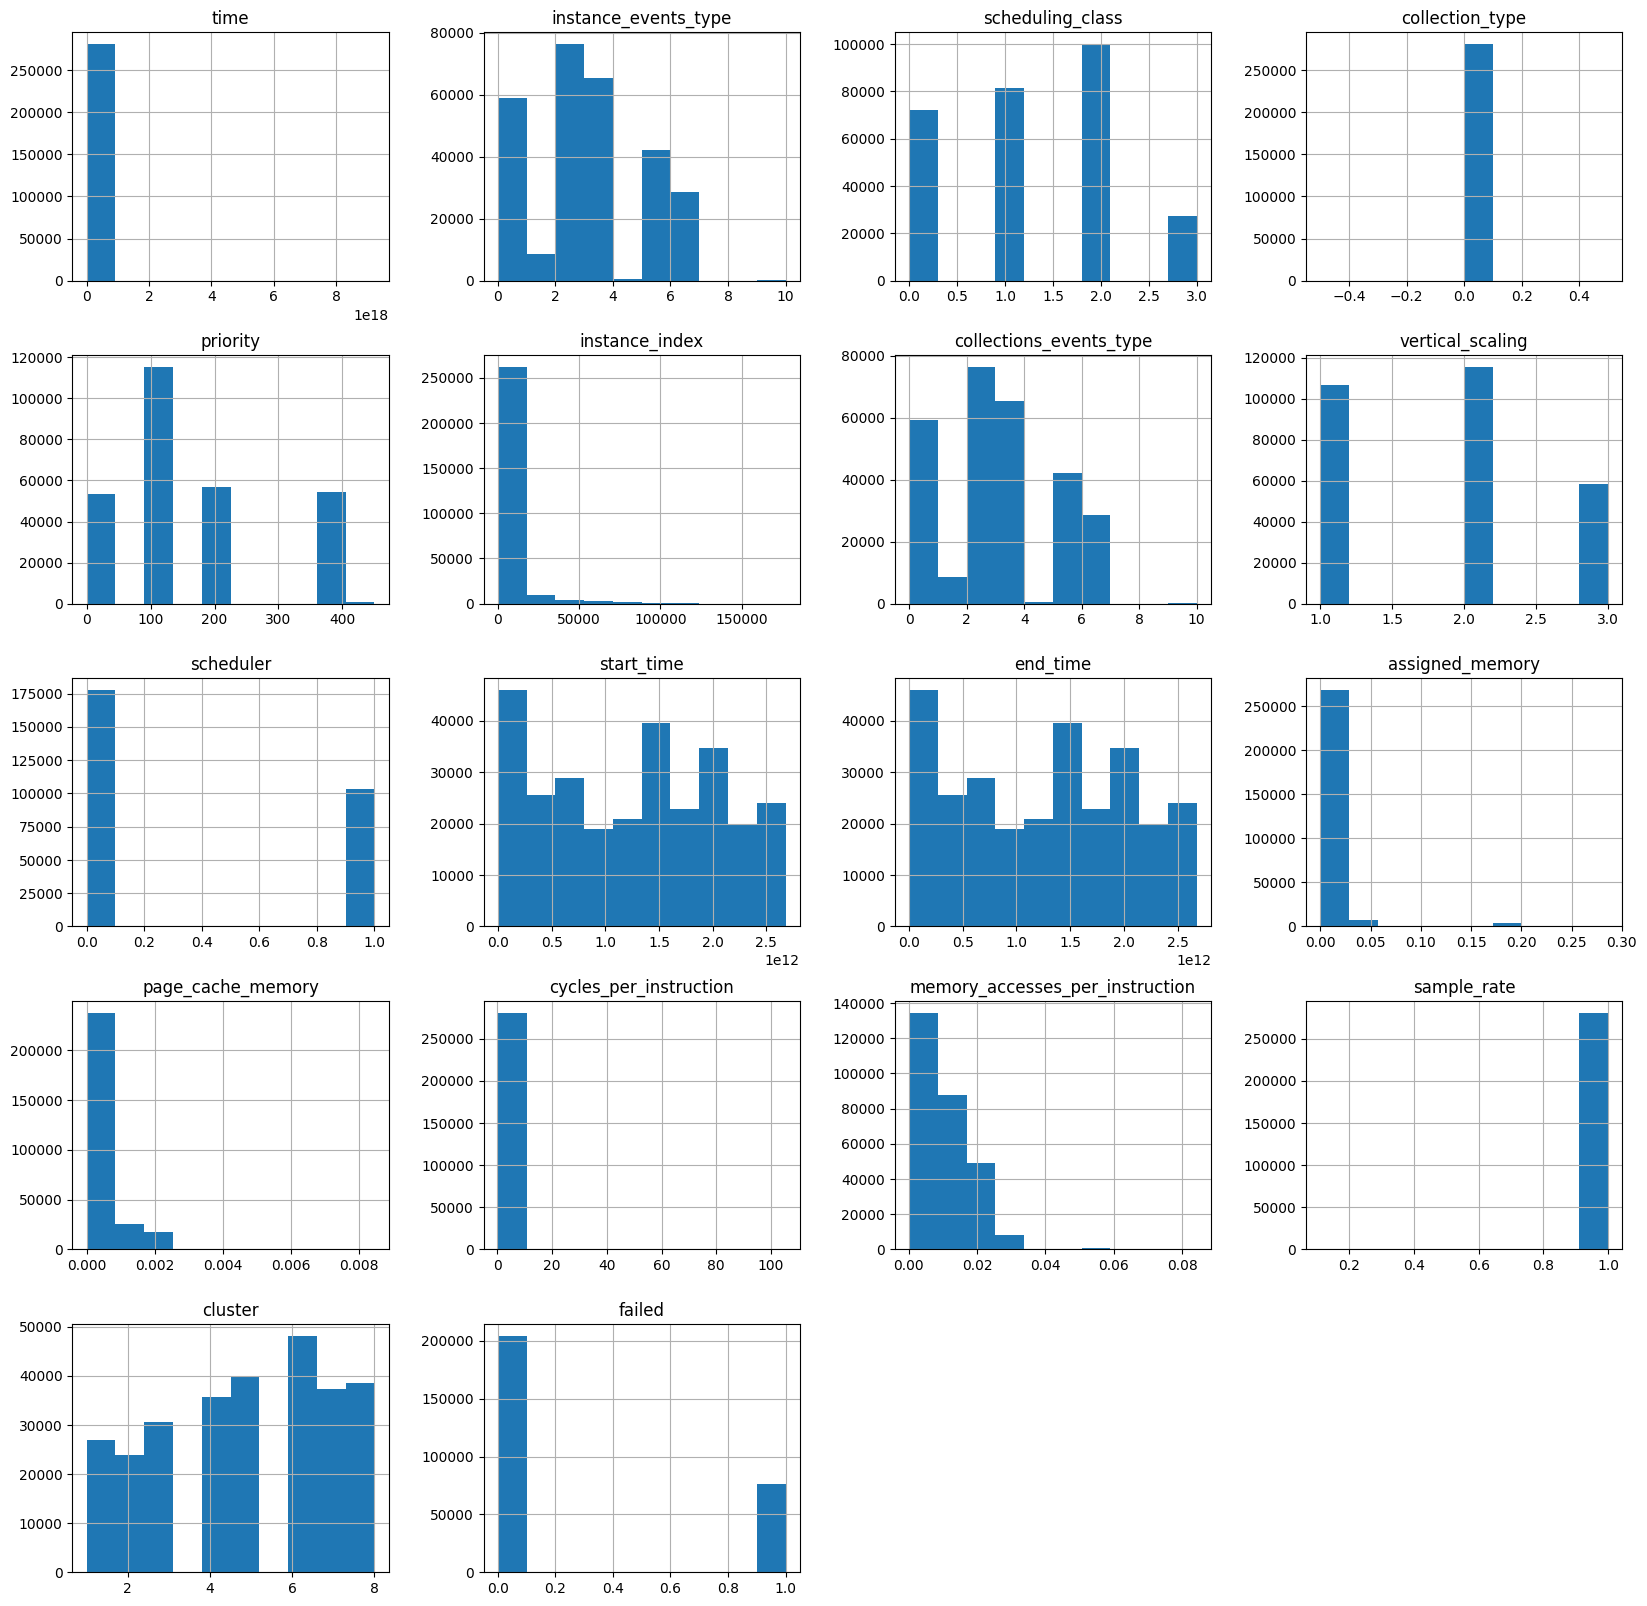

In [ ]:
df.hist(figsize=(20,20))

In [ ]:
def check_outlier(DataFrame):
    # DataFrame.hist(figsize=(10,10))
    dic = {}
    for i in DataFrame:
        Q1 = DataFrame[i].quantile(0.25)
        Q3 = DataFrame[i].quantile(0.75)
        IQR = Q3-Q1
        up = Q3 + 1.5*IQR
        low = Q1 - 1.5*IQR

        if DataFrame[(DataFrame[i] > up) | (DataFrame[i] < low)].any(axis=None):
            dic[i] = 1
        else:
            dic[i] = 0
    return pd.Series(dic)

check_outlier(df)

time                               1
instance_events_type               1
scheduling_class                   0
collection_type                    0
priority                           1
instance_index                     1
collections_events_type            1
vertical_scaling                   0
scheduler                          0
start_time                         0
end_time                           0
assigned_memory                    1
page_cache_memory                  1
cycles_per_instruction             1
memory_accesses_per_instruction    1
sample_rate                        1
cluster                            0
failed                             0
dtype: int64

In [ ]:
def outlier_solver(DataFrame):
    for i in DataFrame:
        Q1 = DataFrame[i].quantile(0.25)
        Q3 = DataFrame[i].quantile(0.75)
        IQR = Q3 - Q1
        up_lim = Q3 + 1.5 * IQR
        low_lim = Q1 - 1.5 * IQR
        DataFrame.loc[DataFrame[i] > up_lim,i] = up_lim
        DataFrame.loc[DataFrame[i] < low_lim,i] = low_lim
    return check_outlier(DataFrame)

outlier_solver(df)

time                               0
instance_events_type               0
scheduling_class                   0
collection_type                    0
priority                           0
instance_index                     0
collections_events_type            0
vertical_scaling                   0
scheduler                          0
start_time                         0
end_time                           0
assigned_memory                    0
page_cache_memory                  0
cycles_per_instruction             0
memory_accesses_per_instruction    0
sample_rate                        0
cluster                            0
failed                             0
dtype: int64

array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'instance_events_type'}>,
        <Axes: title={'center': 'scheduling_class'}>,
        <Axes: title={'center': 'collection_type'}>],
       [<Axes: title={'center': 'priority'}>,
        <Axes: title={'center': 'instance_index'}>,
        <Axes: title={'center': 'collections_events_type'}>,
        <Axes: title={'center': 'vertical_scaling'}>],
       [<Axes: title={'center': 'scheduler'}>,
        <Axes: title={'center': 'start_time'}>,
        <Axes: title={'center': 'end_time'}>,
        <Axes: title={'center': 'assigned_memory'}>],
       [<Axes: title={'center': 'page_cache_memory'}>,
        <Axes: title={'center': 'cycles_per_instruction'}>,
        <Axes: title={'center': 'memory_accesses_per_instruction'}>,
        <Axes: title={'center': 'sample_rate'}>],
       [<Axes: title={'center': 'cluster'}>,
        <Axes: title={'center': 'failed'}>, <Axes: >, <Axes: >]],
      dtype=object)

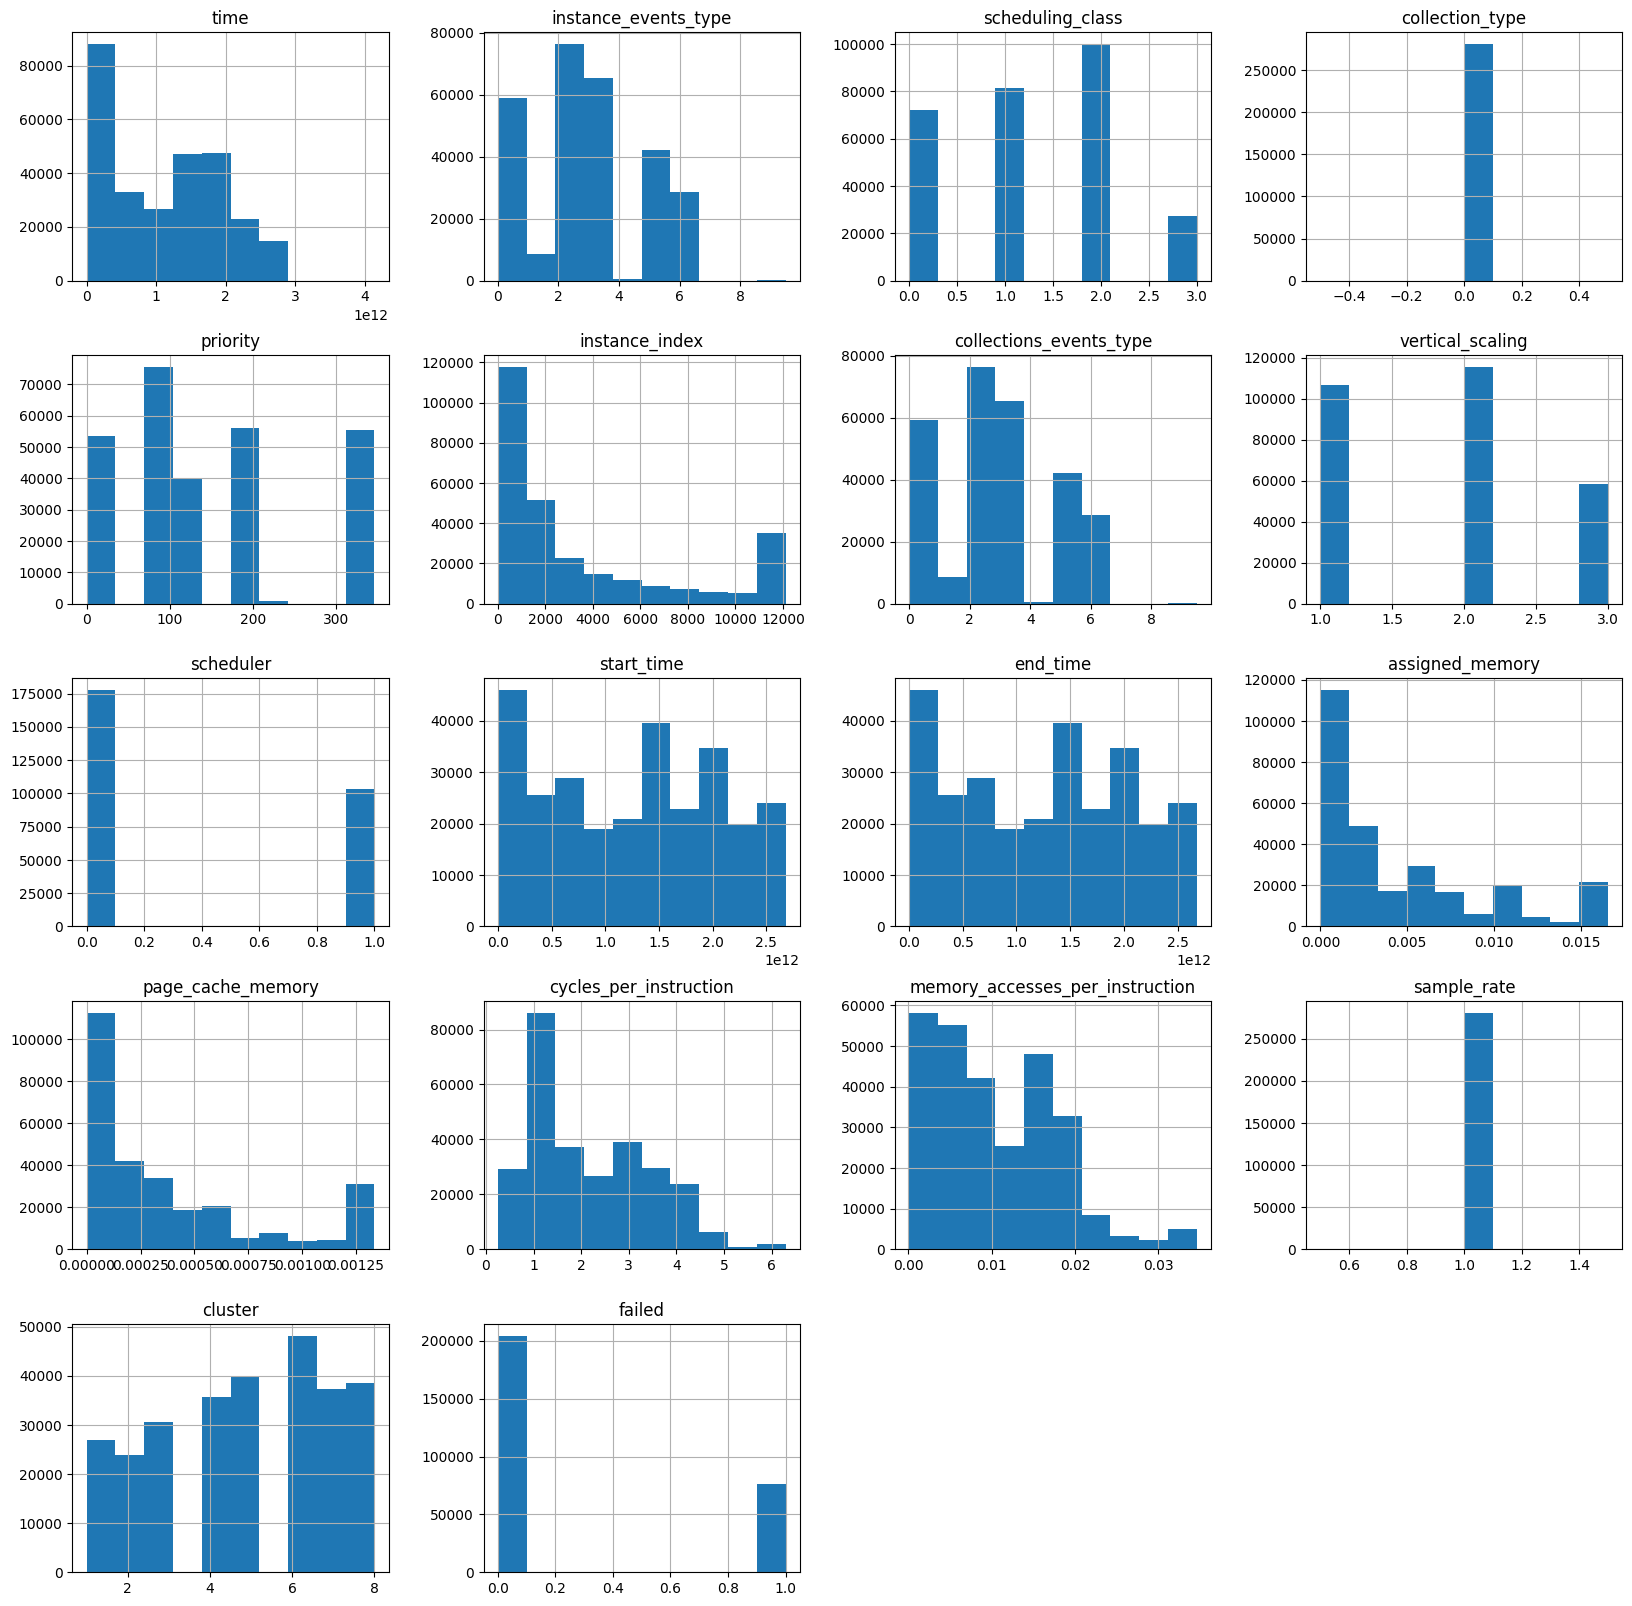

In [ ]:
df.hist(figsize=(20,20))

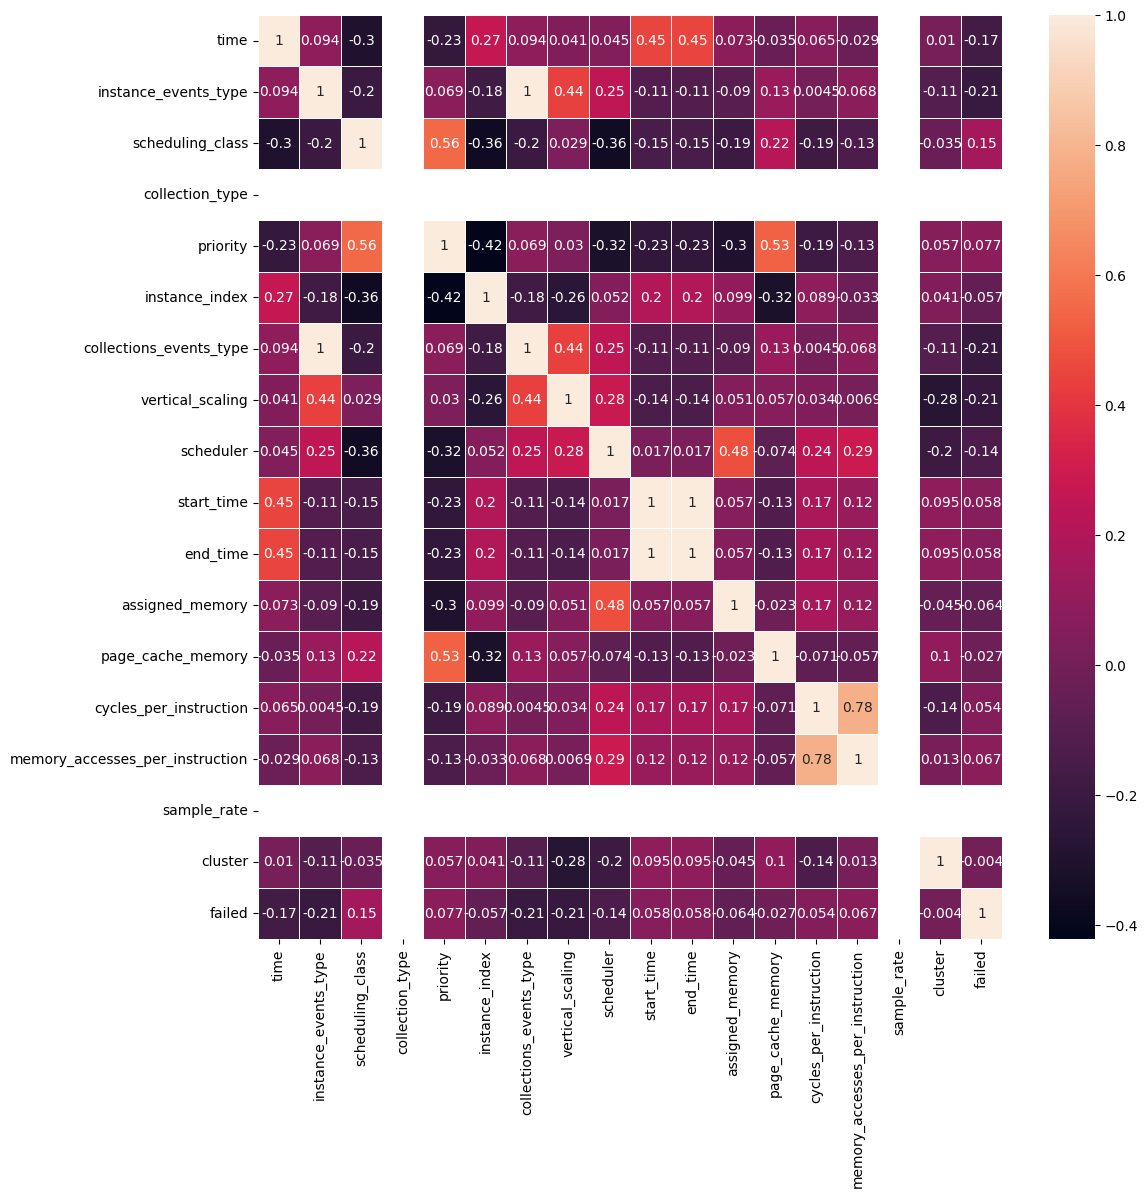

In [ ]:
import matplotlib.pyplot as plt

def Correlation_figure(DataFrame):
    plt.figure(figsize=(12,12))
    sns.heatmap(DataFrame.corr(),annot=True,linewidths=0.6)

Correlation_figure(df)

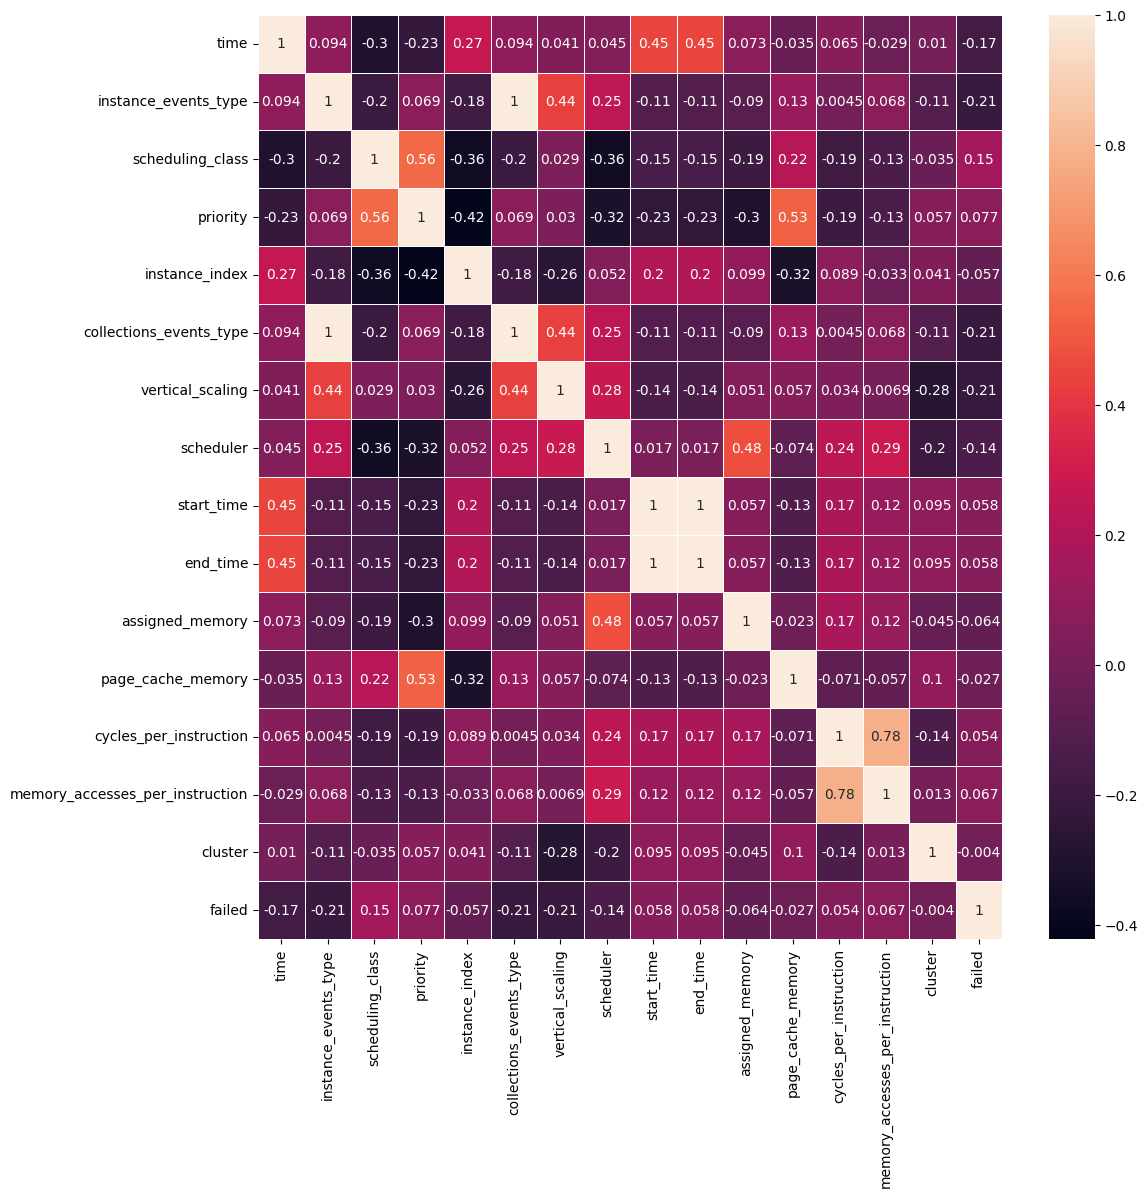

In [ ]:
df.drop(['collection_type','sample_rate'], axis=1, inplace=True)
Correlation_figure(df)

<Axes: xlabel='cluster', ylabel='count'>

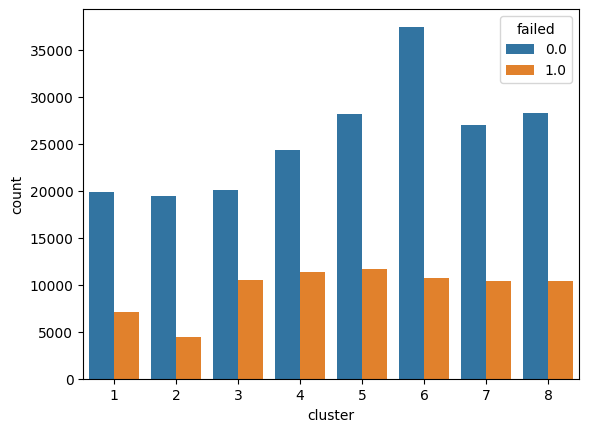

In [ ]:
import seaborn as sns

sns.countplot(df, x="cluster", hue="failed")

<Axes: xlabel='cluster', ylabel='time'>

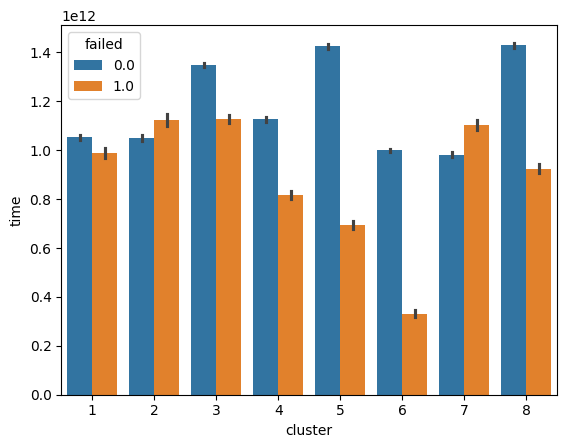

In [ ]:
sns.barplot(df, x="cluster", y="time", hue="failed")

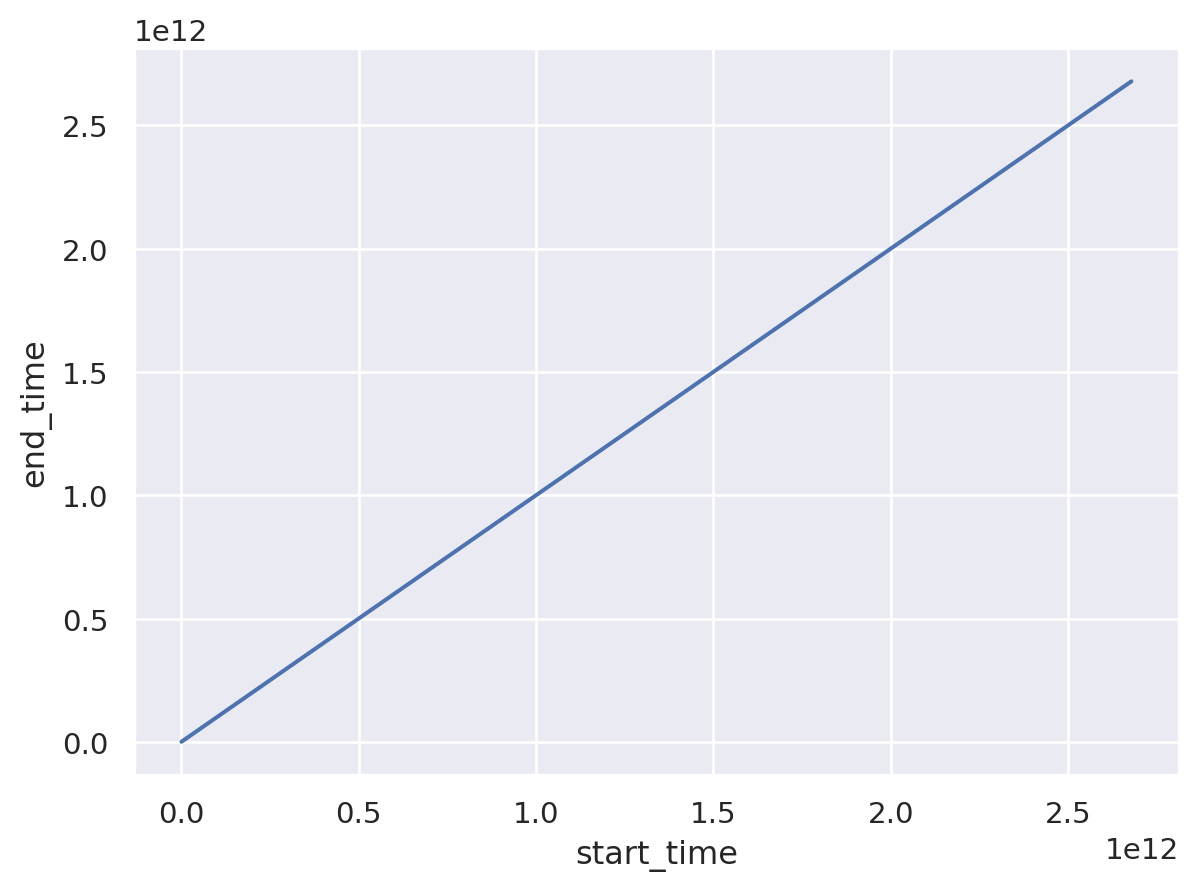

In [ ]:
import seaborn.objects as so

so.Plot(df, "start_time", "end_time").add(so.Line())

##### Construção do Modelo de Decision-Tree

- Referencia: https://www.kaggle.com/code/vaibavthalapathy/logistic-regression

Rodar esse código fora do colab:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Carregar os datasets
google = pd.read_csv('datasets/google.csv')

print("\tGoogle:\n", 50*"-")
print(google.head())
print(google.info())

# Pré-processamento do Google Dataset
google['time'] = pd.to_datetime(google['time'], unit='ns')
google.set_index('time', inplace=True)

# Preencher valores ausentes apenas nas colunas numéricas
numeric_cols = google.select_dtypes(include=[np.number]).columns
google[numeric_cols] = google[numeric_cols].fillna(google[numeric_cols].mean())

# Extrair valores de memória dos dicionários em average_usage e maximum_usage
def extract_memory_value(value):
    if isinstance(value, str):
        value_dict = eval(value)
        return value_dict.get('memory', np.nan)
    return value

google['average_usage_memory'] = google['average_usage'].apply(extract_memory_value)
google['maximum_usage_memory'] = google['maximum_usage'].apply(extract_memory_value)

# Selecionar features e target para o modelo de árvore de decisão
X_google = google[['scheduling_class', 'priority', 'assigned_memory', 'average_usage_memory', 'maximum_usage_memory']]
y_google = google['vertical_scaling']  # Supondo que 'vertical_scaling' é a métrica de estado atual

# Dividir os dados em conjuntos de treinamento e teste
X_train_google, X_test_google, y_train_google, y_test_google = train_test_split(X_google, y_google, test_size=0.2, random_state=42)

# Criar e treinar o modelo de árvore de decisão
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_google, y_train_google)

# Avaliar o modelo
y_pred_google = dt_model.predict(X_test_google)
mse_google = mean_squared_error(y_test_google, y_pred_google)
mae_google = mean_absolute_error(y_test_google, y_pred_google)
r2_google = r2_score(y_test_google, y_pred_google)

print(f'MSE do modelo de árvore de decisão: {mse_google}')
print(f'MAE do modelo de árvore de decisão: {mae_google}')
print(f'R² do modelo de árvore de decisão: {r2_google}')

# Visualizar a importância das features
importances = dt_model.feature_importances_
feature_names = X_google.columns
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Importância das features:\n", feature_importances)

# Salvar o modelo de árvore de decisão
joblib.dump(dt_model, 'decision_tree_model.pkl')

# Função para prever o estado atual da aplicação
def predict_application_state(input_data):
    model = joblib.load('decision_tree_model.pkl')
    prediction = model.predict(input_data)
    return prediction

###### Testar o Modelo - Incluindo redimensionamento

In [ ]:
import pandas as pd
import numpy as np
import joblib
from model import predict_application_state

# Função para realizar testes adicionais com o modelo
def test_model():
    # Carregar o dataset completo para extrair exemplos reais
    google = pd.read_csv('datasets/google.csv')
    google['time'] = pd.to_datetime(google['time'], unit='ns')
    google.set_index('time', inplace=True)

    # Preencher valores ausentes apenas nas colunas numéricas
    numeric_cols = google.select_dtypes(include=[np.number]).columns
    google[numeric_cols] = google[numeric_cols].fillna(google[numeric_cols].mean())

    # Extrair valores de memória dos dicionários em average_usage e maximum_usage
    def extract_memory_value(value):
        if isinstance(value, str):
            value_dict = eval(value)
            return value_dict.get('memory', np.nan)
        return value

    google['average_usage_memory'] = google['average_usage'].apply(extract_memory_value)
    google['maximum_usage_memory'] = google['maximum_usage'].apply(extract_memory_value)

    # Selecionar exemplos de falha
    test_data_fail = google[google['event'] == 'FAIL'][['scheduling_class', 'priority', 'assigned_memory', 'average_usage_memory', 'maximum_usage_memory']].head(3)

    # Selecionar exemplos de sucesso (aplicações saudáveis)
    test_data_success = google[google['event'] == 'FINISH'][['scheduling_class', 'priority', 'assigned_memory', 'average_usage_memory', 'maximum_usage_memory']].head(3)

    print("Testando aplicações saudáveis:")
    predictions_success = predict_application_state(test_data_success)
    for i, prediction in enumerate(predictions_success):
        if prediction < 1:
            print(f'A aplicação {i} precisa de mais recursos: {prediction}')
        elif prediction < 2:
            print(f'A aplicação {i} está em risco: {prediction}')
        else:
            print(f'A aplicação {i} está em estado saudável: {prediction}')

    print("\nTestando aplicações com falha:")
    predictions_fail = predict_application_state(test_data_fail)
    for i, prediction in enumerate(predictions_fail):
        if prediction < 1:
            print(f'A aplicação {i} precisa de mais recursos: {prediction}')
        elif prediction < 2:
            print(f'A aplicação {i} está em risco: {prediction}')
        else:
            print(f'A aplicação {i} está em estado saudável: {prediction}')

# Executar a função de teste
if __name__ == "__main__":
    test_model()


In [ ]:
import pandas as pd

# Carregar o dataset
abilene = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ASD/datasets/abilene.csv')
abilene.head()

,timestamp,source,target,demand_value
0,2004-03-01 00:00:00,ATLAM5,ATLAng,0.522208
1,2004-03-01 00:00:00,ATLAM5,CHINng,1.641339
2,2004-03-01 00:00:00,ATLAM5,DNVRng,0.335728
3,2004-03-01 00:00:00,ATLAM5,HSTNng,0.413032
4,2004-03-01 00:00:00,ATLAM5,IPLSng,0.489875


#### Análise Gráfica: Artigo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os datasets
google = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ASD/datasets/google.csv')

google['time'] = pd.to_datetime(google['time'], unit='ns')
google.set_index('time', inplace=True)

# Preencher valores ausentes apenas nas colunas numéricas
numeric_cols = google.select_dtypes(include=[np.number]).columns
google[numeric_cols] = google[numeric_cols].fillna(google[numeric_cols].mean())

# Extrair valores de memória dos dicionários em average_usage e maximum_usage
def extract_memory_value(value):
    if isinstance(value, str):
        value_dict = eval(value)
        return value_dict.get('memory', np.nan)
    return value

google['Uso Médio de Memória'] = google['average_usage'].apply(extract_memory_value)
google['Uso Máximo de Memória'] = google['maximum_usage'].apply(extract_memory_value)
google['Memória Atribuída'] = google['assigned_memory']

<Figure size 1200x800 with 0 Axes>

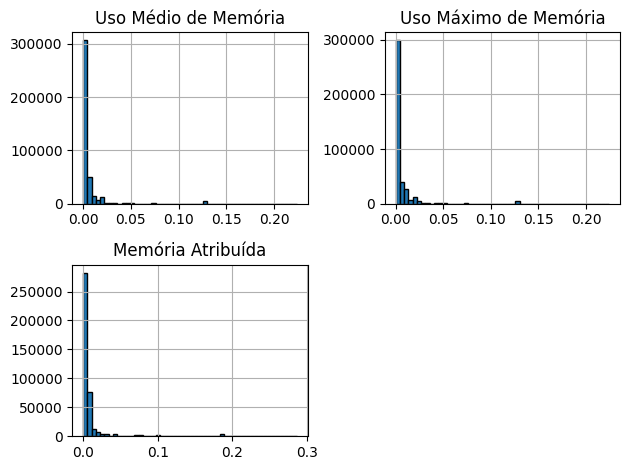

In [ ]:
# Distribuição das Features
plt.figure(figsize=(12, 8))
google[['Uso Médio de Memória', 'Uso Máximo de Memória', 'Memória Atribuída']].hist(bins=50, edgecolor='black')
plt.tight_layout()
plt.show()

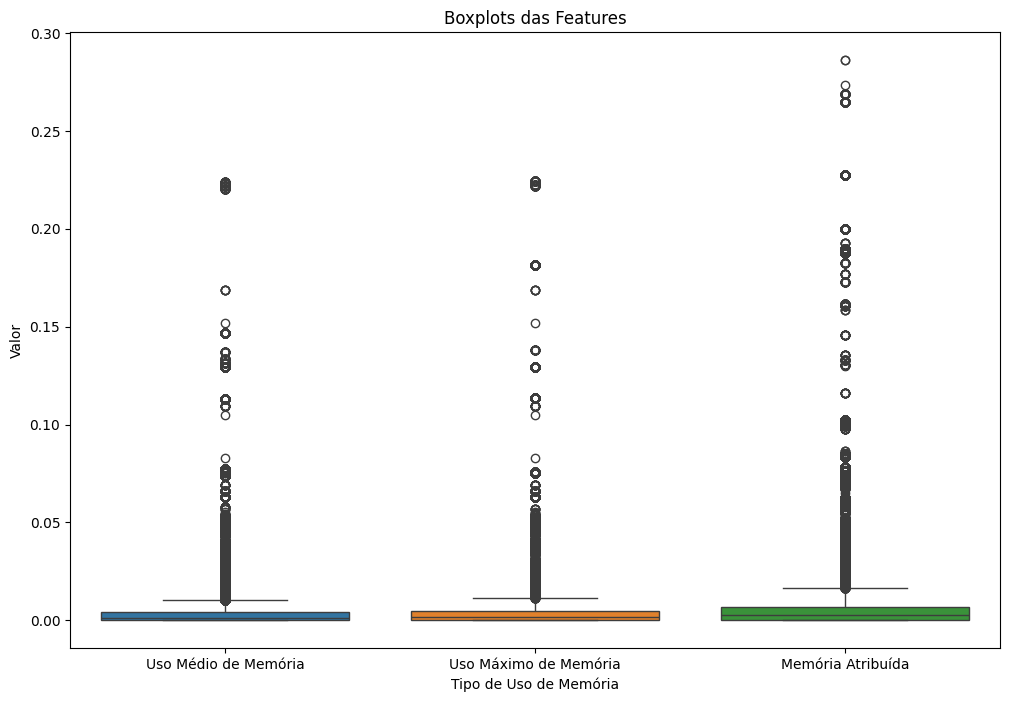

In [ ]:
# Boxplots das Features
plt.figure(figsize=(12, 8))
sns.boxplot(data=google[['Uso Médio de Memória', 'Uso Máximo de Memória', 'Memória Atribuída']])
plt.ylabel('Valor')
plt.xlabel('Tipo de Uso de Memória')
plt.title('Boxplots das Features')
plt.show()


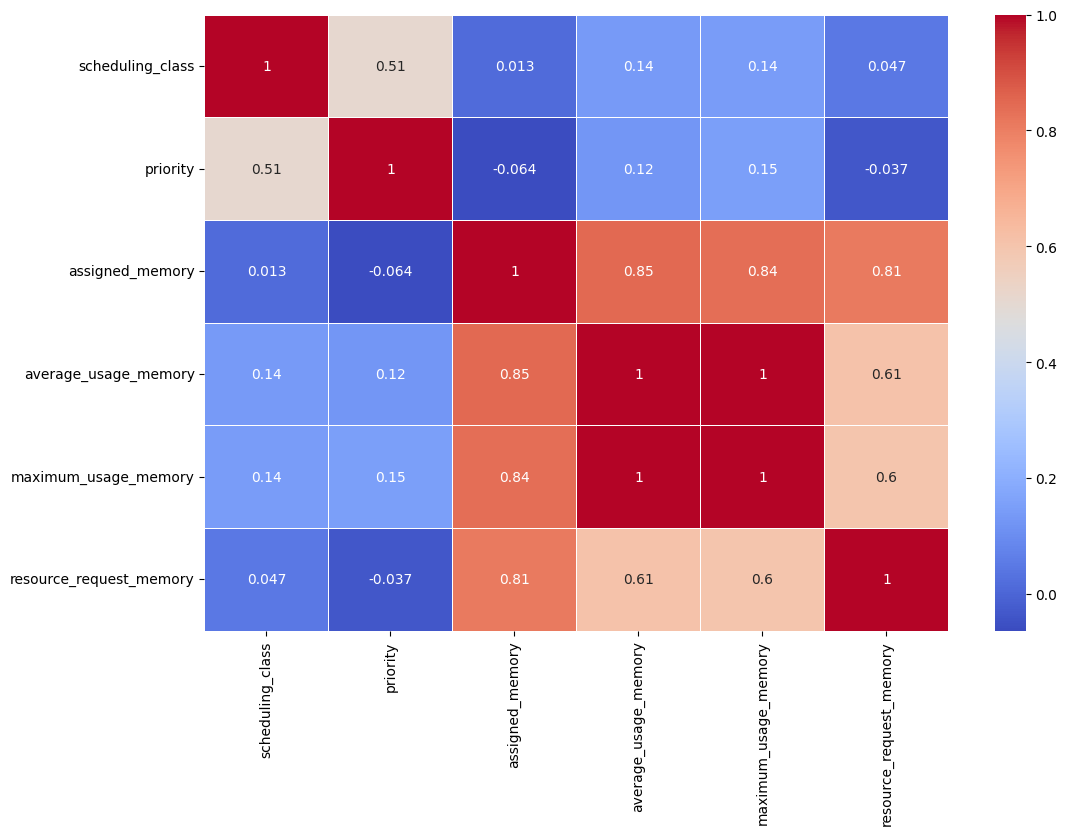

In [ ]:
# Heatmap de Correlação
plt.figure(figsize=(12, 8))
corr_matrix = google[['scheduling_class', 'priority', 'assigned_memory', 'average_usage_memory', 'maximum_usage_memory', 'resource_request_memory']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()


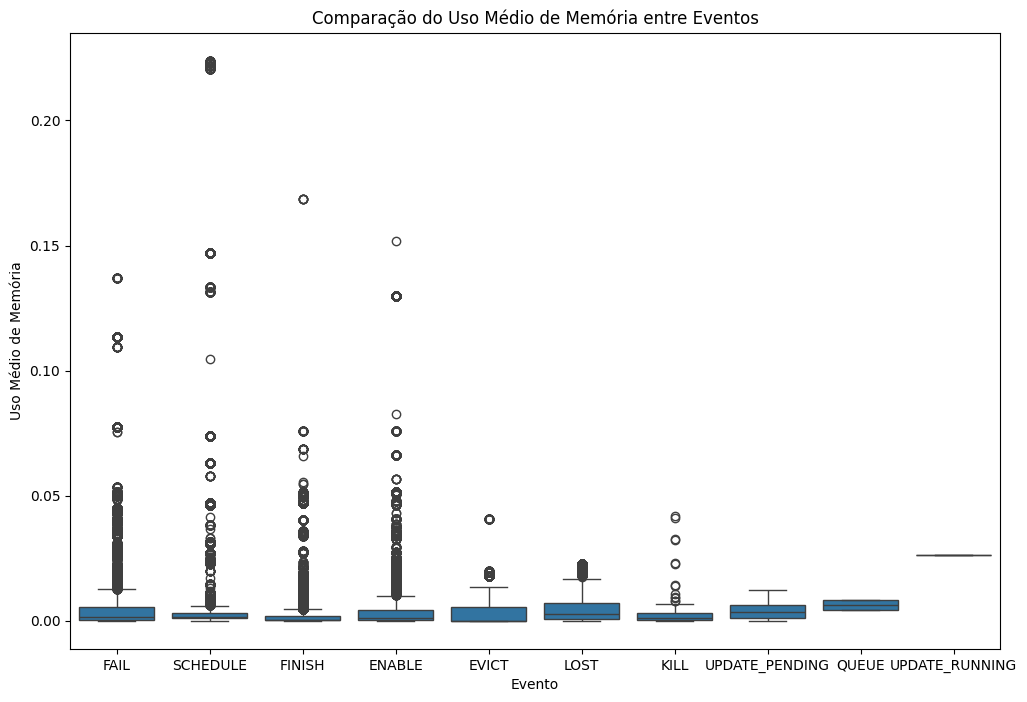

In [ ]:
# Comparação entre Eventos
plt.figure(figsize=(12, 8))
sns.boxplot(x='event', y='Uso Médio de Memória', data=google)
plt.title('Comparação do Uso Médio de Memória entre Eventos')
plt.xlabel('Evento')
plt.ylabel('Uso Médio de Memória')
plt.show()


#### LSTM - Modelo 2



In [ ]:
# Função para criar sequências
def create_sequences(data, target, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x = data[i:i + window_size]
        y = target[i + window_size]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib

google = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ASD/datasets/google.csv')
google.head()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [ ]:
# Pré-processamento do Google Dataset
google['time'] = pd.to_datetime(google['time'], unit='ns')
google.set_index('time', inplace=True)

# Preencher valores ausentes apenas nas colunas numéricas
numeric_cols = google.select_dtypes(include=[np.number]).columns
google[numeric_cols] = google[numeric_cols].fillna(google[numeric_cols].mean())

In [ ]:
# Extrair valores de memória dos dicionários em average_usage e maximum_usage
def extract_memory_value(value):
    if isinstance(value, str):
        value_dict = eval(value)
        return value_dict.get('memory', np.nan)
    return value

In [ ]:
google['average_usage_memory'] = google['average_usage'].apply(extract_memory_value)
google['maximum_usage_memory'] = google['maximum_usage'].apply(extract_memory_value)
google['resource_request_memory'] = google['resource_request'].apply(extract_memory_value)

# Selecionar as features relevantes e o target
features = ['scheduling_class', 'priority', 'assigned_memory', 'average_usage_memory', 'maximum_usage_memory', 'resource_request_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction']
X_google = google[features]
y_google = google['vertical_scaling']

# Remover quaisquer linhas com NaN em X_google ou y_google
data = pd.concat([X_google, y_google], axis=1).dropna()
X_google = data[features]
y_google = data['vertical_scaling']

In [ ]:
# Normalizar os dados
scaler = StandardScaler()
X_google_scaled = scaler.fit_transform(X_google)

# Criar sequências de dados e targets
window_size = 24
X_sequences, y_sequences = create_sequences(X_google_scaled, y_google.values, window_size)

# Verificar as formas das sequências
print(X_sequences.shape)
print(y_sequences.shape)

(400345, 24, 8)
(400345,)


In [ ]:
# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X_sequences, y_sequences, test_size=0.2, random_state=42)

# Reshape para [amostras, janelas de tempo, features]
X_train = X_train.reshape((X_train.shape[0], window_size, X_google.shape[1]))
X_test = X_test.reshape((X_test.shape[0], window_size, X_google.shape[1]))


In [ ]:
# Construir o modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(window_size, X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))  # Camada LSTM adicional
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))  # Camada LSTM adicional
model.add(Dropout(0.2))
model.add(Dense(1))  # Saída para prever o tráfego

model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Treinamento
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/50
8007/8007 [==============================] - 388s 47ms/step - loss: 0.5874 - val_loss: 0.5679
Epoch 2/50
8007/8007 [==============================] - 381s 48ms/step - loss: 0.5747 - val_loss: 0.5679
Epoch 3/50
8007/8007 [==============================] - 358s 45ms/step - loss: 0.5708 - val_loss: 0.5697
Epoch 4/50
8007/8007 [==============================] - 356s 44ms/step - loss: 0.5687 - val_loss: 0.5678
Epoch 5/50
8007/8007 [==============================] - 374s 47ms/step - loss: 0.5674 - val_loss: 0.5683
Epoch 6/50
8007/8007 [==============================] - 353s 44ms/step - loss: 0.5669 - val_loss: 0.5678
Epoch 7/50
8007/8007 [==============================] - 355s 44ms/step - loss: 0.5664 - val_loss: 0.5693
Epoch 8/50
8007/8007 [==============================] - 372s 47ms/step - loss: 0.5662 - val_loss: 0.5680
Epoch 9/50
8007/8007 [==============================] - 361s 45ms/step - loss: 0.5659 - val_loss: 0.5678
Epoch 10/50
8007/8007 [==============================] 

In [ ]:
# Avaliação do modelo
y_pred = model.predict(X_test)

# Inverter a normalização
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_scaled = scaler.inverse_transform(y_pred)


2503/2503 [==============================] - 33s 13ms/step


ValueError: non-broadcastable output operand with shape (80069,1) doesn't match the broadcast shape (80069,8)

In [ ]:
# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(y_test_scaled, label='Verdadeiro')
plt.plot(y_pred_scaled, label='Previsto')
plt.legend()
plt.show()

In [ ]:
# Métrica de avaliação
mse = mean_squared_error(y_test_scaled, y_pred_scaled)
print(f'Mean Squared Error: {mse}')

In [ ]:
# Salvar o modelo
model.save('lstm_model.h5')
joblib.dump(scaler, 'scaler.pkl')